# 4:Implementing a GPT model from scratch to generate text

## 4.1:Coding an LLM architecture

In [1]:
GPT_CONFIG_124M={
    "vocab_size": 50257,         # Vocabulary size
    "context_length": 1024,     # Context length
    "emb_dim": 768,             # Embedding dimension
    "n_heads": 12,              # Number of attention heads
    "n_layers": 12,             # Number of layers
    "drop_rate": 0.1,           # Dropout rate
    "qkv_bias": False           # Query_Key_Value bias
}

In [2]:
import torch
import torch.nn as nn


class DummyGPTModel(nn.Module):
    def __init__(self,cfg):
        super().__init__()
        self.tok_emb=nn.Embedding(cfg["vocab_size"],cfg["emb_dim"])
        self.pos_emb=nn.Embedding(cfg["context_length"],cfg["emb_dim"])
        self.drop_emb=nn.Dropout(cfg["drop_rate"])

        # Use a placeholder for TransformerBlock
        self.trf_blocks=nn.Sequential(
            *[DummyTransformerBlock(cfg) for _ in range(cfg["n_layers"])])

        # Use a placeholder for LayerNorm
        self.final_norm=DummyLayerNorm(cfg["emb_dim"])
        self.out_head=nn.Linear(
            cfg["emb_dim"],cfg["vocab_size"],bias=False
        )

    def forward(self,in_idx):
        batch_size,seq_len=in_idx.shape
        tok_embeds=self.tok_emb(in_idx)
        pos_embeds=self.pos_emb(torch.arange(seq_len,device=in_idx.device))
        x=tok_embeds+pos_embeds
        x=self.drop_emb(x)
        x=self.trf_blocks(x)
        x=self.final_norm(x)
        logits=self.out_head(x)
        return logits


class DummyTransformerBlock(nn.Module):
    def __init__(self,cfg):
        super().__init__()
        # A simple placeholder

    def forward(self,x):
        # This block does nothing and just returns its input.
        return x


class DummyLayerNorm(nn.Module):
    def __init__(self,normalized_shape,eps=1e-5):
        super().__init__()
        # The parameters here are just to mimic the LayerNorm interface

    def forward(self,x):
        # This layer does nothing and just returns its input.
        return x

In [3]:
import tiktoken

tokenizer=tiktoken.get_encoding("gpt2")

batch=[]

txt1="Every effort moves you"
txt2="Every day holds a"

batch.append(torch.tensor(tokenizer.encode(txt1)))
batch.append(torch.tensor(tokenizer.encode(txt2)))
batch=torch.stack(batch,dim=0)
print(batch)

tensor([[6109, 3626, 6100,  345],
        [6109, 1110, 6622,  257]])


In [4]:
batch.shape

torch.Size([2, 4])

In [5]:
torch.manual_seed(123)
model=DummyGPTModel(cfg=GPT_CONFIG_124M)

logits=model(batch)
print("Output shape:",logits.shape)
print(logits)

Output shape: torch.Size([2, 4, 50257])
tensor([[[-0.9289,  0.2748, -0.7557,  ..., -1.6070,  0.2702, -0.5888],
         [-0.4476,  0.1726,  0.5354,  ..., -0.3932,  1.5285,  0.8557],
         [ 0.5680,  1.6053, -0.2155,  ...,  1.1624,  0.1380,  0.7425],
         [ 0.0447,  2.4787, -0.8843,  ...,  1.3219, -0.0864, -0.5856]],

        [[-1.5474, -0.0542, -1.0571,  ..., -1.8061, -0.4494, -0.6747],
         [-0.8422,  0.8243, -0.1098,  ..., -0.1434,  0.2079,  1.2046],
         [ 0.1355,  1.1858, -0.1453,  ...,  0.0869, -0.1590,  0.1552],
         [ 0.1666, -0.8138,  0.2307,  ...,  2.5035, -0.3055, -0.3083]]],
       grad_fn=<UnsafeViewBackward0>)


## 4.2:Normalizing activations with layer normalization

In [6]:
torch.manual_seed(123)

batch_example=torch.randn(2,100)
batch_example

tensor([[ 3.3737e-01, -1.7778e-01, -3.0353e-01, -5.8801e-01,  3.4861e-01,
          6.6034e-01, -2.1964e-01, -3.7917e-01,  7.6711e-01, -1.1925e+00,
          6.9835e-01, -1.4097e+00,  1.7938e-01,  1.8951e+00,  4.9545e-01,
          2.6920e-01, -7.7020e-02, -1.0205e+00, -1.6896e-01,  9.1776e-01,
          1.5810e+00,  1.3010e+00,  1.2753e+00, -2.0095e-01,  4.9647e-01,
         -1.5723e+00,  9.6657e-01, -1.1481e+00, -1.1589e+00,  3.2547e-01,
         -6.3151e-01, -2.8400e+00, -1.3250e+00,  1.7843e-01, -2.1338e+00,
          1.0524e+00, -3.8848e-01, -9.3435e-01, -4.9914e-01, -1.0867e+00,
          8.8054e-01,  1.5542e+00,  6.2662e-01, -1.7549e-01,  9.8284e-02,
         -9.3507e-02,  2.6621e-01, -5.8504e-01,  8.7684e-01,  1.6221e+00,
         -1.4779e+00,  1.1331e+00, -1.2203e+00,  1.3139e+00,  1.0533e+00,
          1.3881e-01,  2.2473e+00, -8.0364e-01, -2.8084e-01,  7.6968e-01,
         -6.5956e-01, -7.9793e-01,  1.8383e-01,  2.2935e-01,  5.1463e-01,
          9.9376e-01, -2.5873e-01, -1.

In [7]:
layer =nn.Sequential(nn.Linear(100,1000),nn.ReLU())
out=layer(batch_example)
out

tensor([[0.0000, 0.0000, 0.6500,  ..., 0.6055, 0.0584, 0.0890],
        [0.0000, 0.0000, 0.9601,  ..., 0.0000, 0.6433, 0.0000]],
       grad_fn=<ReluBackward0>)

In [8]:
out.shape

torch.Size([2, 1000])

In [9]:
mean=out.mean(dim=-1,keepdim=True)
mean

tensor([[0.2482],
        [0.2297]], grad_fn=<MeanBackward1>)

In [10]:
var=out.var(dim=-1,keepdim=True)
var

tensor([[0.1226],
        [0.1029]], grad_fn=<VarBackward0>)

In [11]:
normed=((out-mean)/torch.sqrt(var))
normed.var(dim=-1,keepdim=True,unbiased=False)

tensor([[0.9990],
        [0.9990]], grad_fn=<VarBackward0>)

In [12]:
torch.set_printoptions(sci_mode=False)

In [13]:
class LayerNorm(nn.Module):
    def __init__(self,emb_dim):
        super().__init__()
        self.eps=1e-5
        self.scale=nn.Parameter(torch.ones(emb_dim))
        self.shift=nn.Parameter(torch.zeros(emb_dim))

    def forward(self,x):
        mean=x.mean(dim=-1,keepdim=True)
        var=x.var(dim=-1,keepdim=True ,unbiased=False)
        norm_x=(x-mean) /torch.sqrt(var +self.eps)
        return self.scale*norm_x+self.shift

In [14]:
ln=LayerNorm(1000)
outputs_normed=ln(out)

In [15]:
outputs_normed

tensor([[-0.7091, -0.7091,  1.1481,  ...,  1.0208, -0.5422, -0.4547],
        [-0.7164, -0.7164,  2.2784,  ..., -0.7164,  1.2904, -0.7164]],
       grad_fn=<AddBackward0>)

In [16]:
outputs_normed.mean(dim=-1,keepdim=True)

tensor([[     0.0000],
        [    -0.0000]], grad_fn=<MeanBackward1>)

In [17]:
outputs_normed.var(dim=-1,keepdim=True)

tensor([[1.0009],
        [1.0009]], grad_fn=<VarBackward0>)

## 4.3:Implementing a feed forward network with GELU activations

In [18]:
class GELU(nn.Module):
    def __init__(self):
        super().__init__()

    def forward(self,x):
        return 0.5*x*(1+torch.tanh(
            torch.sqrt(torch.tensor(2.0/torch.pi))*
            (x+0.044715*torch.pow(x,3))
        ))

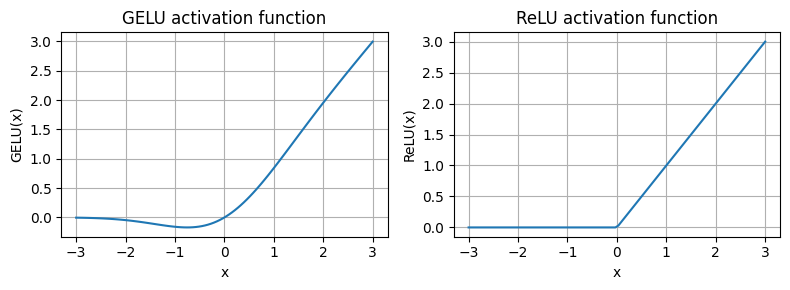

In [19]:
import matplotlib.pyplot as plt

gelu,relu=GELU(),nn.ReLU()

# Some sample data
x=torch.linspace(-3,3,100)
y_gelu,y_relu=gelu(x),relu(x)

plt.figure(figsize=(8,3))
for i,(y,label) in enumerate(zip([y_gelu,y_relu],["GELU","ReLU"]),1):
    plt.subplot(1,2,i)
    plt.plot(x,y)
    plt.title(f"{label} activation function")
    plt.xlabel("x")
    plt.ylabel(f"{label}(x)")
    plt.grid(True)

plt.tight_layout()
plt.show()

In [20]:
768 -> 3072 -> 768

SyntaxError: invalid syntax (3399403963.py, line 1)

In [21]:
class FeedForward(nn.Module):
    def __init__(self,cfg):
        super().__init__()
        self.layers=nn.Sequential(
            nn.Linear(cfg["emb_dim"],4*cfg["emb_dim"]),
            GELU(),
            nn.Linear(4*cfg["emb_dim"],cfg["emb_dim"]),
        )

    def forward(self,x):
        return self.layers(x)

In [22]:
ffn=FeedForward(GPT_CONFIG_124M)

In [23]:
x=torch.rand(2,3,768)
ffn(x).shape

torch.Size([2, 3, 768])

In [24]:
ffn.layers[0].weight

Parameter containing:
tensor([[ 0.0003, -0.0027, -0.0175,  ..., -0.0248, -0.0236, -0.0221],
        [ 0.0323, -0.0116,  0.0290,  ..., -0.0318,  0.0082, -0.0360],
        [-0.0126, -0.0170,  0.0227,  ..., -0.0268, -0.0120,  0.0037],
        ...,
        [-0.0111, -0.0346,  0.0276,  ...,  0.0164, -0.0357,  0.0341],
        [-0.0087,  0.0254, -0.0279,  ...,  0.0285,  0.0355, -0.0230],
        [-0.0007,  0.0317,  0.0324,  ...,  0.0114,  0.0350, -0.0130]],
       requires_grad=True)

## 4.4:Adding shortcut connections

In [25]:
class ExampleDeepNeuralNetwork(nn.Module):
    def __init__(self,layer_sizes,use_shortcut):
        super().__init__()
        self.use_shortcut=use_shortcut
        self.layers=nn.ModuleList([
            nn.Sequential(nn.Linear(layer_sizes[0],layer_sizes[1]),GELU()),
            nn.Sequential(nn.Linear(layer_sizes[1],layer_sizes[2]),GELU()),
            nn.Sequential(nn.Linear(layer_sizes[2],layer_sizes[3]),GELU()),
            nn.Sequential(nn.Linear(layer_sizes[3],layer_sizes[4]),GELU()),
            nn.Sequential(nn.Linear(layer_sizes[4],layer_sizes[5]),GELU())
        ])
                          

    def forward(self,x):
        for layer in self.layers:
            # Compute the output of the current layer
            layer_output=layer(x)
            # Check if shortcut can be applied
            if self.use_shortcut and x.shape == layer_output.shape:
                x=x+layer_output
            else:
                x=layer_output
        return x


def print_gradients(model,x):
    # Forward pass
    output=model(x)
    target=torch.tensor([[0.]])

    # Calculate loss based on how close the target
    # and output are
    loss=nn.MSELoss()
    loss=loss(output,target)

    #Backward pass to calculate the gradients
    loss.backward()

    for name,param in model.named_parameters():
        if 'weight' in name:
            # Print the mean absolute gradient of the weights
            print(f"{name} has gradient mean of {param.grad.abs().mean().item()}")

In [26]:
layer_sizes=[3,3,3,3,3,1]

In [27]:
sample_input=torch.tensor([[1.,0.,-1.]])

In [28]:
torch.manual_seed(123)
model_without_shortcut=ExampleDeepNeuralNetwork(
    layer_sizes,use_shortcut=False
)
print_gradients(model_without_shortcut,sample_input)

layers.0.0.weight has gradient mean of 0.00020173587836325169
layers.1.0.weight has gradient mean of 0.0001201116101583466
layers.2.0.weight has gradient mean of 0.0007152041653171182
layers.3.0.weight has gradient mean of 0.001398873864673078
layers.4.0.weight has gradient mean of 0.005049646366387606


In [29]:
torch.manual_seed(123)
model_without_shortcut=ExampleDeepNeuralNetwork(
    layer_sizes,use_shortcut=True
)
print_gradients(model_without_shortcut,sample_input)

layers.0.0.weight has gradient mean of 0.22169792652130127
layers.1.0.weight has gradient mean of 0.20694106817245483
layers.2.0.weight has gradient mean of 0.32896995544433594
layers.3.0.weight has gradient mean of 0.2665732502937317
layers.4.0.weight has gradient mean of 1.3258541822433472


## 4.5:Connecting attention and linear layers in a transformer block

In [33]:
from ch04.previous_chapters import MultiHeadAttention

class TransformerBlock(nn.Module):
    def __init__(self,cfg):
        super().__init__()
        self.att=MultiHeadAttention(
            d_in=cfg["emb_dim"],
            d_out=cfg["emb_dim"],
            context_length=cfg["context_length"],
            num_heads=cfg["n_heads"],
            dropout=cfg["drop_rate"],
            qkv_bias=cfg["qkv_bias"])
        self.ff=FeedForward(cfg)
        self.norm1=LayerNorm(cfg["emb_dim"])
        self.norm2=LayerNorm(cfg["emb_dim"])
        self.drop_shortcut=nn.Dropout(cfg["drop_rate"])

    def forward(self,x):
        # Shortcut connection for attention block
        shortcut=x
        x=self.norm1(x)
        x=self.att(x)  # Shape [batch_size,num_tokens,emb_size]
        x=self.drop_shortcut(x)
        x=x+shortcut  # Add the original input back

        # Shortcut connection for feed forward block
        shortcut=x
        x=self.norm2(x)
        x=self.ff(x)
        x=self.drop_shortcut(x)
        x=x+shortcut  # Add the original input back

        return x

In [34]:
torch.manual_seed(123)

x=torch.rand(2,4,768)
block=TransformerBlock(GPT_CONFIG_124M)
output=block(x)

In [35]:
x.shape

torch.Size([2, 4, 768])

In [36]:
output.shape

torch.Size([2, 4, 768])

## 4.6:Coding the GPT model

In [38]:
import tiktoken

tokenizer=tiktoken.get_encoding("gpt2")

batch=[]

txt1="Every effort moves you"
txt2="Every day holds a"

batch.append(torch.tensor(tokenizer.encode(txt1)))
batch.append(torch.tensor(tokenizer.encode(txt2)))
batch=torch.stack(batch,dim=0)
print(batch)

tensor([[6109, 3626, 6100,  345],
        [6109, 1110, 6622,  257]])


In [39]:
class GPTModel(nn.Module):
    def __init__(self,cfg):
        super().__init__()
        self.tok_emb=nn.Embedding(cfg["vocab_size"],cfg["emb_dim"])
        self.pos_emb=nn.Embedding(cfg["context_length"],cfg["emb_dim"])
        self.drop_emb=nn.Dropout(cfg["drop_rate"])

        self.trf_blocks=nn.Sequential(
            *[TransformerBlock(cfg) for _ in range(cfg["n_layers"])])

        self.final_norm=LayerNorm(cfg["emb_dim"])
        self.out_head=nn.Linear(
            cfg["emb_dim"],cfg["vocab_size"],bias=False
        )

    def forward(self,in_idx):
        batch_size,seq_len=in_idx.shape
        tok_embeds=self.tok_emb(in_idx)
        pos_embeds=self.pos_emb(torch.arange(seq_len,device=in_idx.device))
        x=tok_embeds+pos_embeds
        x=self.drop_emb(x)
        x=self.trf_blocks(x)
        x=self.final_norm(x)
        logits=self.out_head(x)
        return logits

In [40]:
torch.manual_seed(123)

model=GPTModel(GPT_CONFIG_124M)
out=model(batch)

In [47]:
model.tok_emb.weight.shape

torch.Size([50257, 768])

In [48]:
model.out_head.weight.shape

torch.Size([50257, 768])

In [41]:
batch.shape

torch.Size([2, 4])

In [42]:
out.shape

torch.Size([2, 4, 50257])

In [43]:
batch.numel()

8

In [44]:
total_params=sum(p.numel() for p in model.parameters())
total_params

163009536

In [49]:
print(f"{total_params-model.out_head.weight.numel():,}")

124,412,160


In [ ]:
GPT_CONFIG_124M={
    "vocab_size": 50257,         # Vocabulary size
    "context_length": 1024,     # Context length
    "emb_dim": 768,             # Embedding dimension
    "n_heads": 12,              # Number of attention heads
    "n_layers": 12,             # Number of layers
    "drop_rate": 0.1,           # Dropout rate
    "qkv_bias": False           # Query_Key_Value bias
}

- Exercise: you can try the following other configurations, which are referenced in the GPT-2 paper, as well.

- **GPT2-small** (the 124M configuration we already implemented):
  - "emb_dim" = 768
  - "n_layers" = 12
  - "n_heads" = 12

- **GPT2-medium**:
  - "emb_dim" = 1024
  - "n_layers" = 24
  - "n_heads" = 16

- **GPT2-large**:
  - "emb_dim" = 1280
  - "n_layers" = 36
  - "n_heads" = 20

- **GPT2-XL**:
  - "emb_dim" = 1600
  - "n_layers" = 48
  - "n_heads" = 25

In [54]:
torch.argmax(torch.tensor([0.001,0.000001,0.003]))

tensor(2)

In [55]:
torch.softmax(out[:,-1,:],dim=-1).shape

torch.Size([2, 50257])

## 4.7:Generating text

In [77]:
def generate_text_simple(model,idx,max_new_tokens,context_size):
    for _ in range(max_new_tokens):
        idx_cond=idx[:, -context_size:]

        with torch.no_grad():
            logits=model(idx_cond)
        logits=logits[:,-1,:]

        probas=torch.softmax(logits,dim=-1)

        idx_next=torch.argmax(probas,dim=-1,keepdim=True)

        idx=torch.cat((idx,idx_next),dim=1)

        
    return idx

In [78]:
torch.argmax(torch.tensor([14,1,-2,1,15]))

tensor(4)

In [79]:
start_context="Hello, I am"

encoded=tokenizer.encode(start_context)
print("encoded:",encoded)

encoded: [15496, 11, 314, 716]


In [80]:

encoded_tensor=torch.tensor(encoded).unsqueeze(0)
print("encoded_tensor.shape:",encoded_tensor.shape)

encoded_tensor.shape: torch.Size([1, 4])


In [81]:
encoded_tensor

tensor([[15496,    11,   314,   716]])

In [82]:
out=generate_text_simple(
    model=model,
    idx=encoded_tensor,
    max_new_tokens=6,
    context_size=GPT_CONFIG_124M["context_length"]
)

In [83]:
out

tensor([[15496,    11,   314,   716, 27018, 24086, 28920,  4247, 35410, 29070]])

In [86]:
tokenizer.decode((out.squeeze(0)).tolist())

'Hello, I am Featureimanemptyasionanz Tat'

In [85]:
(out.squeeze(0)).tolist()

[15496, 11, 314, 716, 27018, 24086, 28920, 4247, 35410, 29070]